In [195]:
import os
# Get the name of the current conda environment
env_name = os.getenv("CONDA_DEFAULT_ENV")
print(f"The current Conda environment is: {env_name}")

The current Conda environment is: tensorflow_env


In [196]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

In [197]:
os.chdir('F:\\geodata\\river_runoff_obs')
# Dataset loading
name = '3_xhl_AWI-CM-1-1-MR_ssp126_r1i1p1f1'
csv_path = f"{name}.csv"

In [198]:
usecols = ['time', 'pre', 'tm', 'gr', 'dis','ep']
df_full = pd.read_csv(csv_path, usecols=usecols)
df = df_full.dropna()
df_future = df_full[df_full.dis.isnull()]

In [199]:
df_future

,time,pre,tm,ep,dis,gr
228,2019-01-31,4.906970,-8.004969,9.050104,NaN,0.000000e+00
229,2019-02-28,8.594014,-4.317925,11.714730,NaN,0.000000e+00
230,2019-03-31,10.984167,-1.927772,33.229638,NaN,0.000000e+00
231,2019-04-30,16.574637,3.662698,117.651693,NaN,0.000000e+00
232,2019-05-31,24.107934,11.195995,205.230872,NaN,4.634586e+06
...,...,...,...,...,...,...
1207,2100-08-31,36.218734,23.306795,NaN,NaN,6.004640e+08
1208,2100-09-30,29.199223,16.287284,NaN,NaN,2.472208e+07
1209,2100-10-31,18.681779,5.769840,NaN,NaN,0.000000e+00
1210,2100-11-30,11.643337,-1.268602,NaN,NaN,0.000000e+00


In [200]:
epochs=1000
batch_size=16
file_name = f'{name}_{epochs}_{batch_size}'

In [201]:
# Prepare features (X) and targets (y)
X = df[['pre', 'tm', 'gr']].values  # Inputs: precipitation, temperature, mass balance
y = df[['dis', 'ep']].values         # Outputs: runoff (dis) and evaporation (ep)

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Standardize the data
scaler_X = StandardScaler()
scaler_y = StandardScaler()

X_train = scaler_X.fit_transform(X_train)
X_test = scaler_X.transform(X_test)
y_train = scaler_y.fit_transform(y_train)
y_test = scaler_y.transform(y_test)

# Define the model
model = Sequential([
    Dense(128, activation='relu', input_shape=(X_train.shape[1],)),
    Dense(64, activation='relu'),
    Dense(32, activation='relu'),
    Dense(2)  # Output layer with two units for runoff and evaporation
])

# Compile the model
model.compile(optimizer='adam', loss='mse')

# Train the model
model.fit(X_train, y_train, epochs=epochs, batch_size=batch_size, validation_split=0.2)


Epoch 1/1000
8/8 [==============================] - 0s 12ms/step - loss: 0.8477 - val_loss: 0.5841
Epoch 2/1000
8/8 [==============================] - 0s 4ms/step - loss: 0.5635 - val_loss: 0.4141
Epoch 3/1000
8/8 [==============================] - 0s 4ms/step - loss: 0.4126 - val_loss: 0.2855
Epoch 4/1000
8/8 [==============================] - 0s 4ms/step - loss: 0.2717 - val_loss: 0.1734
Epoch 5/1000
8/8 [==============================] - 0s 4ms/step - loss: 0.1797 - val_loss: 0.1294
Epoch 6/1000
8/8 [==============================] - 0s 4ms/step - loss: 0.1685 - val_loss: 0.1203
Epoch 7/1000
8/8 [==============================] - 0s 4ms/step - loss: 0.1535 - val_loss: 0.1075
Epoch 8/1000
8/8 [==============================] - 0s 4ms/step - loss: 0.1429 - val_loss: 0.0954
Epoch 9/1000
8/8 [==============================] - 0s 4ms/step - loss: 0.1310 - val_loss: 0.0875
Epoch 10/1000
8/8 [==============================] - 0s 4ms/step - loss: 0.1245 - val_loss: 0.0793
Epoch 11/1000
8/8 

In [202]:
# Make predictions
predictions = model.predict(X_test)
predictions_rescaled = scaler_y.inverse_transform(predictions)

# Convert predictions to DataFrame for runoff and evaporation
pred_df = pd.DataFrame(predictions_rescaled, columns=['predicted_runoff', 'predicted_ep'])
print(pred_df.head())

3/3 [==============================] - 0s 1ms/step
   predicted_runoff  predicted_ep
0         27.445732     42.455242
1        256.626465    400.710205
2         20.637566     55.572399
3        220.988449    451.849579
4         70.300110     58.012859


In [203]:
from sklearn.metrics import mean_squared_error
# Calculate predictions and rescale
predictions = model.predict(X_test)
predictions_rescaled = scaler_y.inverse_transform(predictions)

# Separate the predicted and actual values for runoff and evaporation
y_test_rescaled = scaler_y.inverse_transform(y_test)
runoff_observed = y_test_rescaled[:, 0]
evaporation_observed = y_test_rescaled[:, 1]
runoff_predicted = predictions_rescaled[:, 0]
evaporation_predicted = predictions_rescaled[:, 1]

3/3 [==============================] - 0s 2ms/step


In [204]:
# Assuming future_df is loaded and has the same columns as df
# Extract features from future_df
X_full = df_full[['pre', 'tm', 'gr']].values  # Only the input features

# Standardize features based on the training data scaler
X_full_scaled = scaler_X.transform(X_full)

# Predict future runoff and evaporation
full_predictions_scaled = model.predict(X_full_scaled)

# Rescale predictions to original scale
full_predictions = scaler_y.inverse_transform(full_predictions_scaled)

# Convert predictions to DataFrame for readability
df_full[['Projected_Runoff', 'Projected_Evaporation']] = full_predictions
print(df_full[['Projected_Runoff', 'Projected_Evaporation']].head())


38/38 [==============================] - 0s 906us/step
   Projected_Runoff  Projected_Evaporation
0         37.022812               8.328273
1         31.493797              11.838374
2         32.622643              32.194744
3         16.719566             150.550415
4        226.278214             277.714111


In [205]:
# Convert the 'time' column to datetime format if needed
df.loc[:,'time'] = pd.to_datetime(df['time'])
df_full.loc[:,'time'] = pd.to_datetime(df_full['time'])
# Ensure 'time' is set as the index for both DataFrames if not already
df.set_index('time', inplace=True)
df_full.set_index('time', inplace=True)

In [206]:
historic_pred_df = df_full.dropna()
historic_pred_df = historic_pred_df.tail(int(0.3 * len(historic_pred_df)))
# Define the NSE function
def nse(y_true, y_pred):
    return 1 - (np.sum((y_true - y_pred) ** 2) / np.sum((y_true - np.mean(y_true)) ** 2))
# Calculate NSE for runoff and evaporation
nse_runoff = nse(historic_pred_df.dis, historic_pred_df.Projected_Runoff)
nse_evaporation = nse(historic_pred_df.ep, historic_pred_df.Projected_Evaporation)
nse_runoff , nse_evaporation


(0.7795640722509415, 0.940839858937836)

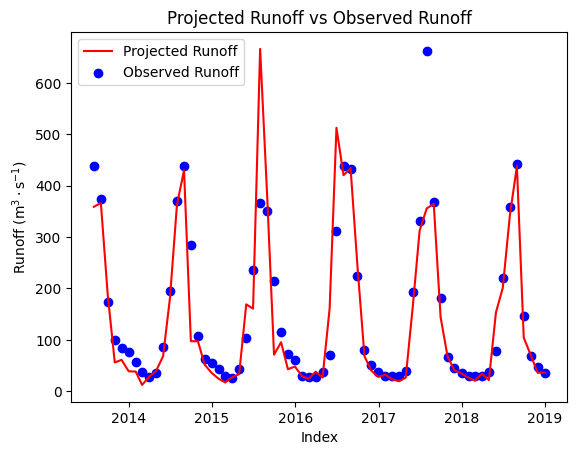

In [207]:
import matplotlib.pyplot as plt

# Plot the line chart for Projected_Runoff
plt.plot(historic_pred_df.index, historic_pred_df['Projected_Runoff'], label='Projected Runoff', color='red')

# Plot the scatter plot for dis
plt.scatter(historic_pred_df.index, historic_pred_df['dis'], label='Observed Runoff', color='b')

# Add labels, title, and legend
plt.xlabel('Index')
plt.ylabel(r'Runoff ($\mathrm{m^3 \cdot s^{-1}}$)')  # Use LaTeX for units
plt.title('Projected Runoff vs Observed Runoff')
plt.legend()

# Show the plot
plt.show()


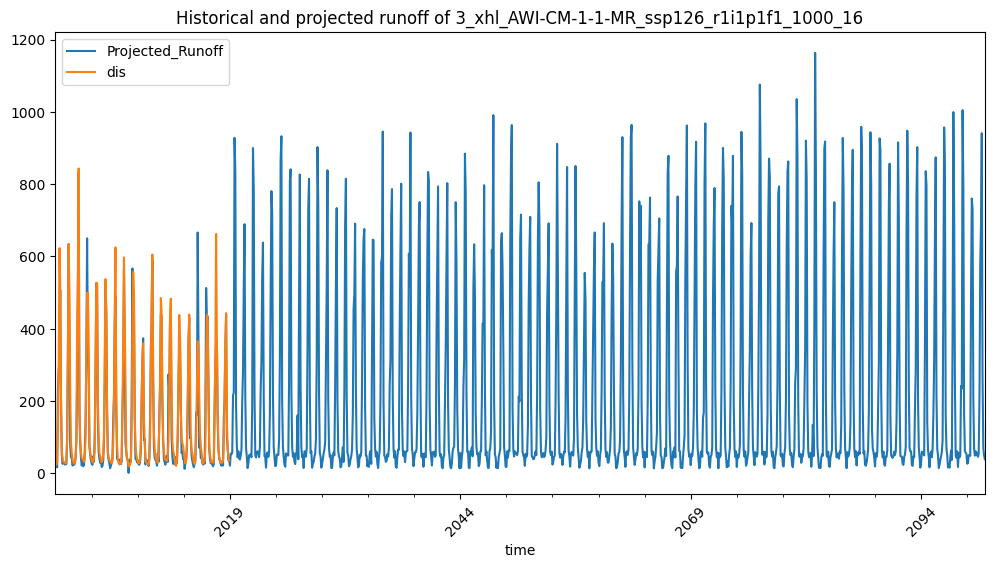

In [208]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Plot with a larger figure size
ax = df_full[[ 'Projected_Runoff','dis']].plot(figsize=(12, 6))
# Optional: Rotate x-tick labels for better readability
plt.xticks(rotation=45)
plt.title(f"Historical and projected runoff of {file_name}")
# Show the plot
plt.show()

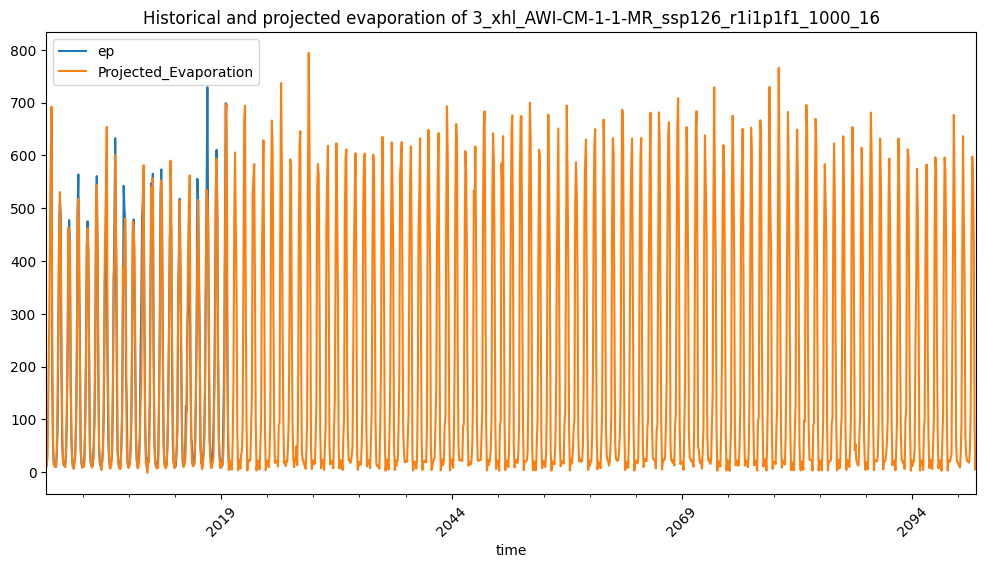

In [209]:
# Plot with a larger figure size
ax = df_full[['ep', 'Projected_Evaporation']].plot(figsize=(12, 6))
# Optional: Rotate x-tick labels for better readability
plt.xticks(rotation=45)
plt.title(f"Historical and projected evaporation of {file_name}")
# Show the plot
plt.show()

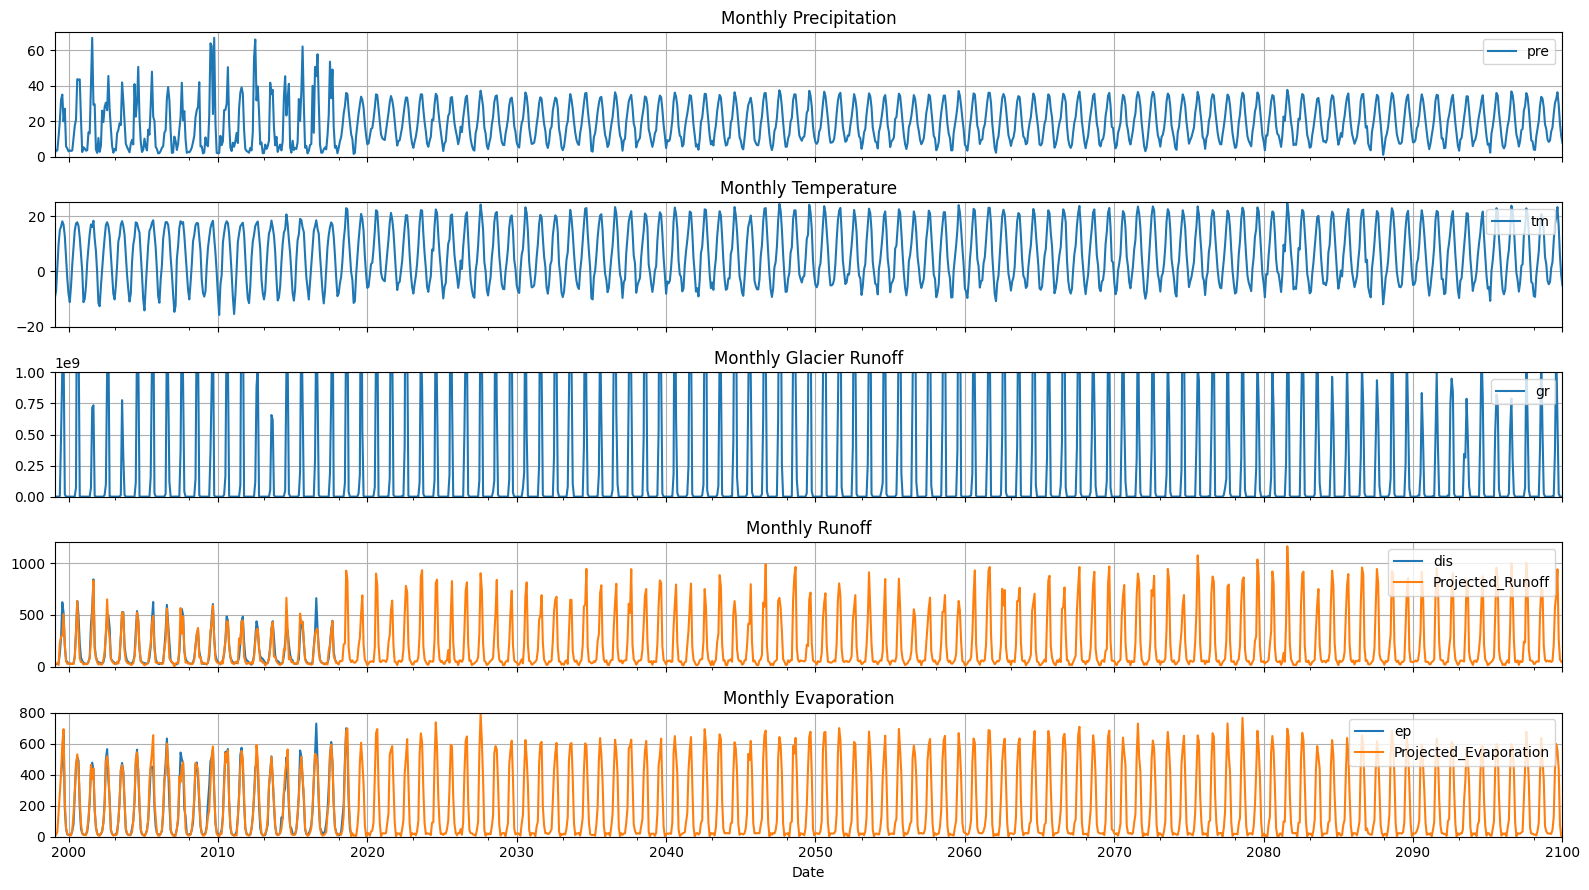

In [214]:
import matplotlib.pyplot as plt

# Define start and end dates as datetime objects
start_date = pd.to_datetime("2000-01-01")
end_date = pd.to_datetime("2100-12-31")

# Generate a range of ticks every 20 years
x_ticks = pd.date_range(start=start_date, end=end_date, freq='10Y')

# Set the size of the figure
fig, axes = plt.subplots(5, 1, figsize=(16, 9), sharex=True,facecolor='w')
title_list = ['Monthly Precipitation','Monthly Temperature','Monthly Glacier Runoff','Monthly Runoff','Monthly Evaporation']

# Define y-axis limits for each plot
y_lims = [(0, 70), (-20, 25), (0, 1e9), (0, 1200), (0, 800)]

# Loop through the columns and set y-axis limits
for i, col in enumerate(['pre', 'tm', 'gr', ['dis', 'Projected_Runoff'], ['ep', 'Projected_Evaporation']]):
    df_full[col].plot(ax=axes[i])
    
    # Set y-axis limits
    axes[i].set_ylim(y_lims[i])
    
    # Optional: Add y-axis label, legend, title, grid, etc.
    # axes[i].set_ylabel(col)  # Set y-axis label to the column name
    axes[i].legend(loc='upper right')  # Optional: add legend
    axes[i].set_title(title_list[i])
    
    # Set x-axis limits
    axes[i].set_xlim([start_date, end_date])
    axes[i].set_xticks(x_ticks)
    
    # Set x-axis labels as years (2000, 2020, ..., 2100)
    axes[i].set_xticklabels([str(date.year) for date in x_ticks], rotation=0)
    
    axes[i].grid(True)  # Optional: add grid for clarity




# Set x-axis label for the entire figure
axes[-1].set_xlabel('Date')  # or adjust label based on your x-axis

# Adjust layout to prevent overlap
plt.tight_layout()
plt.savefig(f'{file_name}.svg')
plt.show()


In [211]:
df_full.to_csv(f"{file_name}_project.csv")

In [212]:
annual_df = df_full.resample('Y').agg({
    'pre': 'sum',  # If there are any NaNs in the group, the sum will be NaN
    'tm': 'mean',  # The mean will also return NaN if there are NaNs in the group
    'gr': 'sum',   # Same for sum, will return NaN if any NaNs are present
    'dis': 'sum',
    'ep': 'sum',
    'Projected_Runoff': 'sum',
    'Projected_Evaporation': 'sum'
}, skipna=False)  # Ensures NaNs are preserved in aggregation

# Reset index if needed
annual_df.reset_index(inplace=True)
annual_df[['ep', 'dis', 'Projected_Runoff',  'Projected_Evaporation']]=annual_df[['ep', 'dis', 'Projected_Runoff',  'Projected_Evaporation']].replace(0, np.nan,)

# Display the result
print(annual_df.head())


        time         pre        tm            gr          dis           ep  \
0 2000-12-31  167.031580  5.609891  2.765423e+09  1991.897012  1837.330240   
1 2001-12-31  217.655588  5.694010  3.948246e+09  2093.942035  2153.939481   
2 2002-12-31  220.363805  5.714420  1.529378e+09  2415.958180  1995.488301   
3 2003-12-31  234.435649  5.231777  2.457829e+09  2129.741421  2126.600207   
4 2004-12-31  181.240886  6.105577  1.123499e+09  1979.293419  2006.147793   

   Projected_Runoff  Projected_Evaporation  
0       1769.011963            2495.204102  
1       1686.204956            2288.927246  
2       2083.975098            1969.171265  
3       2063.147461            2092.848389  
4       1854.522705            1975.191650  


<Axes: >

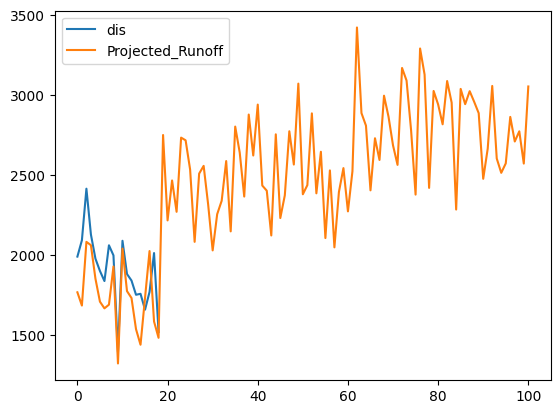

In [213]:
annual_df[['dis', 'Projected_Runoff']].plot()
# plt.ylim(bottom=20000)